<a href="https://colab.research.google.com/github/op1154/MBA_Agents/blob/main/Chunks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -qU langchain langchain-community langchain-openai faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.7/163.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.0/572.0 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [3]:
!pip install google-colab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 89.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.34.2
    Uninstalling requests-2.34.2:
      Successfully uninstalled requests-2.34.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-community 0.4.2 requires requests<3.0.0,>=2.32.5, but you have requests 2.32.4 which is incompatible.


## Baixar os documentos

In [6]:
import os
import getpass
from dotenv import load_dotenv
load_dotenv()

from google.colab import userdata

api_key = userdata.get('OPENAI_API_KEY')

# download das fontes de informação
from langchain_community.document_loaders import TextLoader

documento = TextLoader("/content/GTB_gold_Nov23.txt", encoding="utf-8").load()


In [13]:
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(openai_api_key=api_key)

embeddings_model.model

'text-embedding-ada-002'

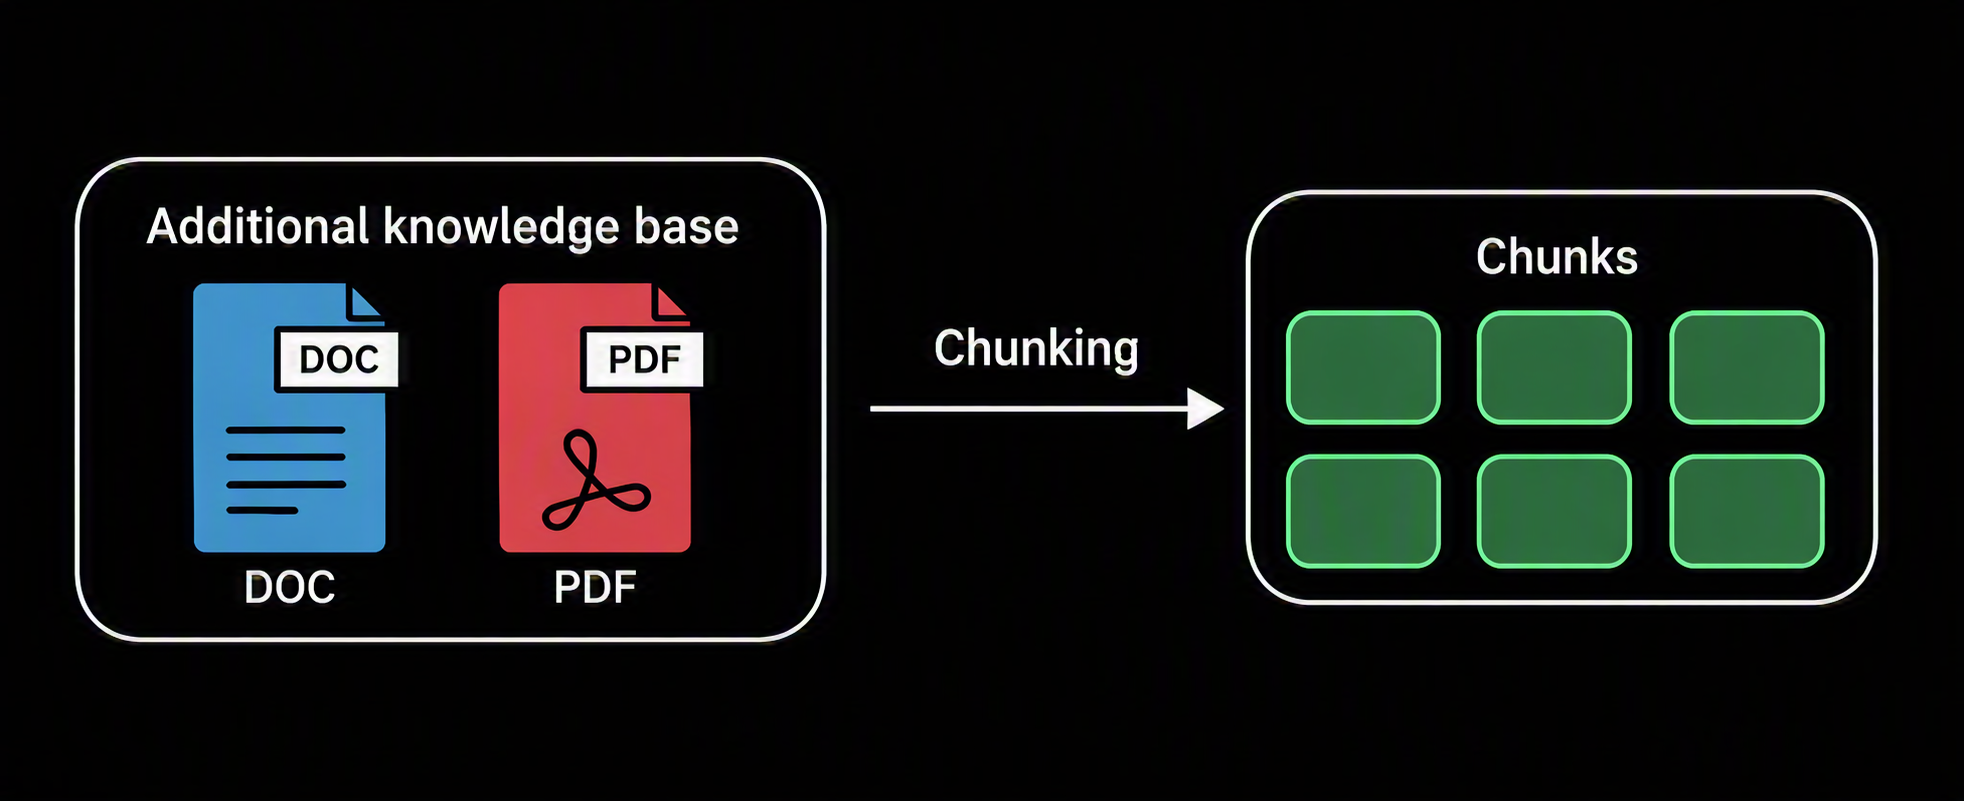

In [7]:
# quebrar os dados em chunks
from langchain_text_splitters import RecursiveCharacterTextSplitter

pedacos = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
).split_documents(documento)

In [8]:
len(pedacos)

5

In [9]:
pedacos[:2]

[Document(metadata={'source': '/content/GTB_gold_Nov23.txt'}, page_content='1\n1 \nVersão: novembro 2023 \n2021 \n \n \n \nPrograma de Cartão da Edição Mastercard Gold  \nGuia de Benefícios \n Informações importantes. Leia e guarde as informações. \n \nEste Guia de Benefícios contém informações detalhadas sobre serviços abrangentes de viagem, seguros \ne assistência aos quais você terá acesso como portador de cartão preferencial. Esses benefícios e serviços \nestão em vigor para portadores do cartão Mastercard Gold elegível a partir de 1 de Novembro de  2023. \nEste Guia substitui qualquer  guia ou comunicação de programa que você recebeu anteriormente. \n \nAs informações contidas neste documento são apresentadas somente com propósito informativo. Não \npretendem  ser  uma  descrição  completa  de  todos  os  termos,  condições,  limitações, exclusões  ou  outras \ndisposições  de  qualquer  programa  ou  benefícios  de  seguro  fornecidos  por,  para,  ou  emitidos  para  a \nMasterc

In [10]:
pedacos[:3]

[Document(metadata={'source': '/content/GTB_gold_Nov23.txt'}, page_content='1\n1 \nVersão: novembro 2023 \n2021 \n \n \n \nPrograma de Cartão da Edição Mastercard Gold  \nGuia de Benefícios \n Informações importantes. Leia e guarde as informações. \n \nEste Guia de Benefícios contém informações detalhadas sobre serviços abrangentes de viagem, seguros \ne assistência aos quais você terá acesso como portador de cartão preferencial. Esses benefícios e serviços \nestão em vigor para portadores do cartão Mastercard Gold elegível a partir de 1 de Novembro de  2023. \nEste Guia substitui qualquer  guia ou comunicação de programa que você recebeu anteriormente. \n \nAs informações contidas neste documento são apresentadas somente com propósito informativo. Não \npretendem  ser  uma  descrição  completa  de  todos  os  termos,  condições,  limitações, exclusões  ou  outras \ndisposições  de  qualquer  programa  ou  benefícios  de  seguro  fornecidos  por,  para,  ou  emitidos  para  a \nMasterc

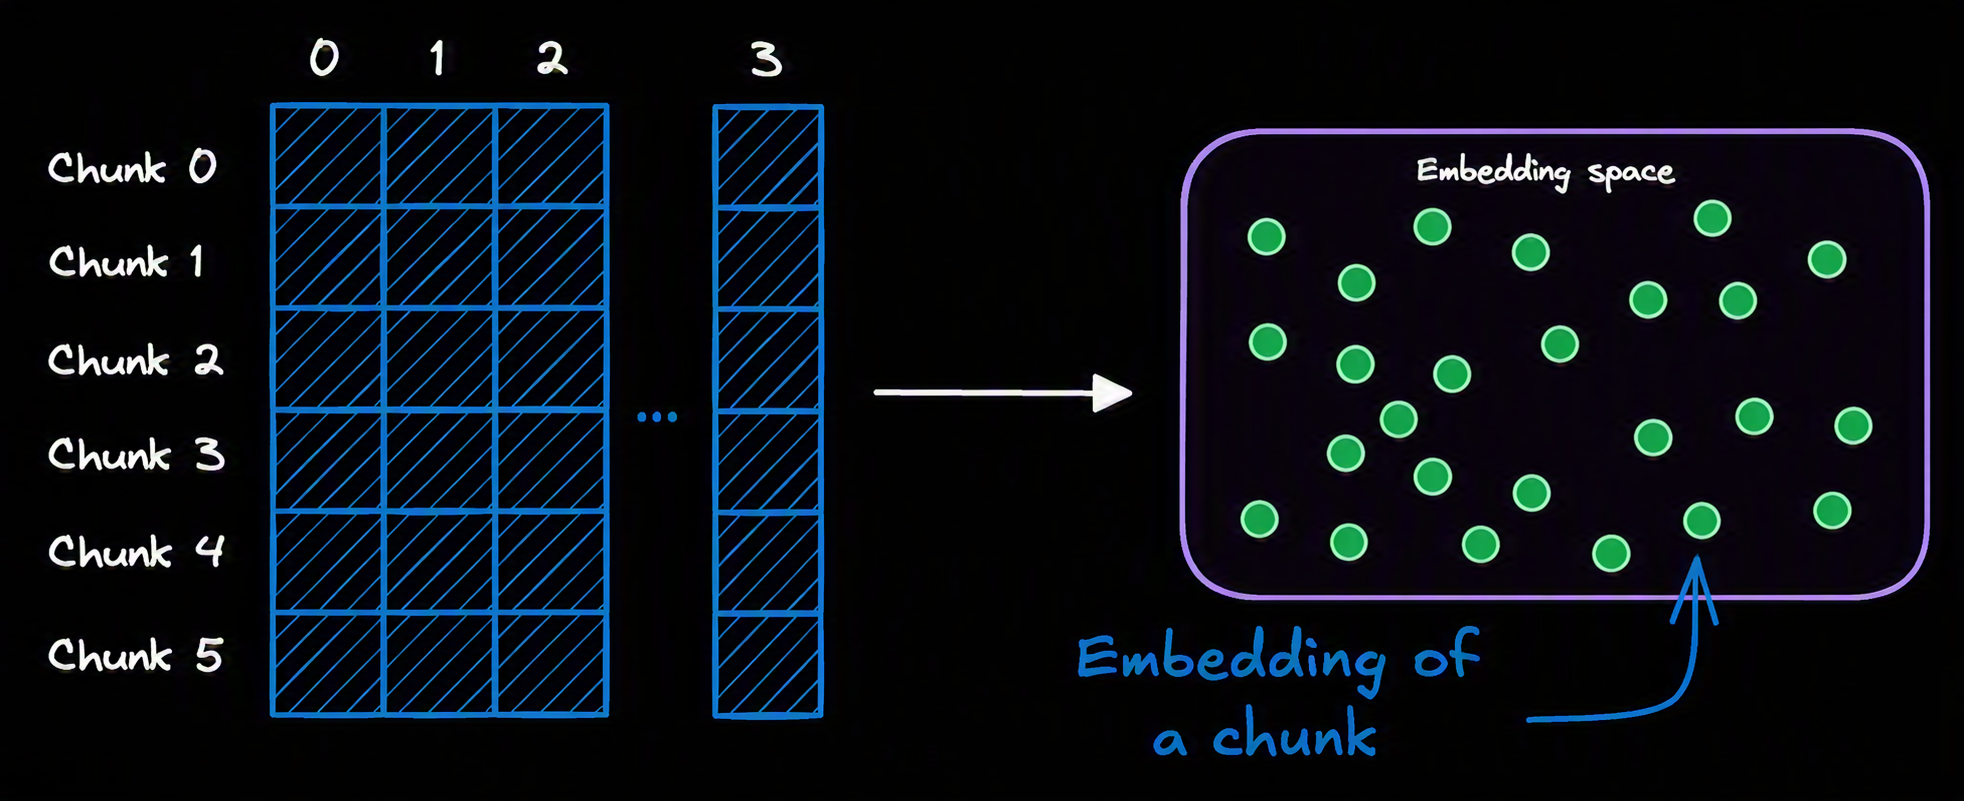

In [14]:
embeddings_model.embed_query(pedacos[0].page_content)

[-0.023375744000077248,
 -0.01277279481291771,
 -0.007980500347912312,
 -0.02883363515138626,
 -0.008126931264996529,
 0.0352499857544899,
 -0.017318816855549812,
 -0.025851763784885406,
 -0.02638424001634121,
 -0.014749615453183651,
 0.016413606703281403,
 0.00568752083927393,
 -0.03953642398118973,
 -0.03391879051923752,
 -0.012799418531358242,
 0.021059468388557434,
 0.024134524166584015,
 -0.008193491026759148,
 0.007042009849101305,
 0.00732821598649025,
 0.02963235042989254,
 0.011741120368242264,
 -0.01566813886165619,
 -0.01408401969820261,
 0.014443441294133663,
 -0.0046891262754797935,
 -0.009258445352315903,
 -0.008958927355706692,
 0.025625459849834442,
 -0.01188755128532648,
 0.02694334089756012,
 0.01369797345250845,
 -0.011295170523226261,
 -0.0019252374768257141,
 0.01682627573609352,
 -0.018490267917513847,
 -0.0015300397062674165,
 -0.016520101577043533,
 0.0029968477319926023,
 -0.006279901601374149,
 -0.004699110519140959,
 0.014350257813930511,
 0.01171449571847915

In [15]:
from langchain_community.vectorstores import InMemoryVectorStore

vectorstore = InMemoryVectorStore.from_documents(
    documents=pedacos, embedding=embeddings_model
)

In [16]:
from re import search
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

In [17]:
retriever.invoke("Proteção de Preço")

[Document(id='a6f47713-a933-4be8-9f11-3137ce9c6b55', metadata={'source': '/content/GTB_gold_Nov23.txt'}, page_content='Seguro Garantia Estendida Original .............................................................................. 3 \nCompra Protegida ........................................................................................................ 8 \nProteção de Preço ....................................................................................................... 12 \nPrincipais Termos e Definições (Em Geral) .................................................................... 17 \nComo Dar Entrada em uma ocorrência/sinistro ........................................................... 18 \nMastercard Global Service .......................................................................................... 21 \nDisposições Gerais e Limitação de Responsabilidade .................................................... 23'),
 Document(id='334cb09c-6578-4d7e-bbb7-04443852349d', 

## Receber a consulta dop Usuário e fazer ao Embedding

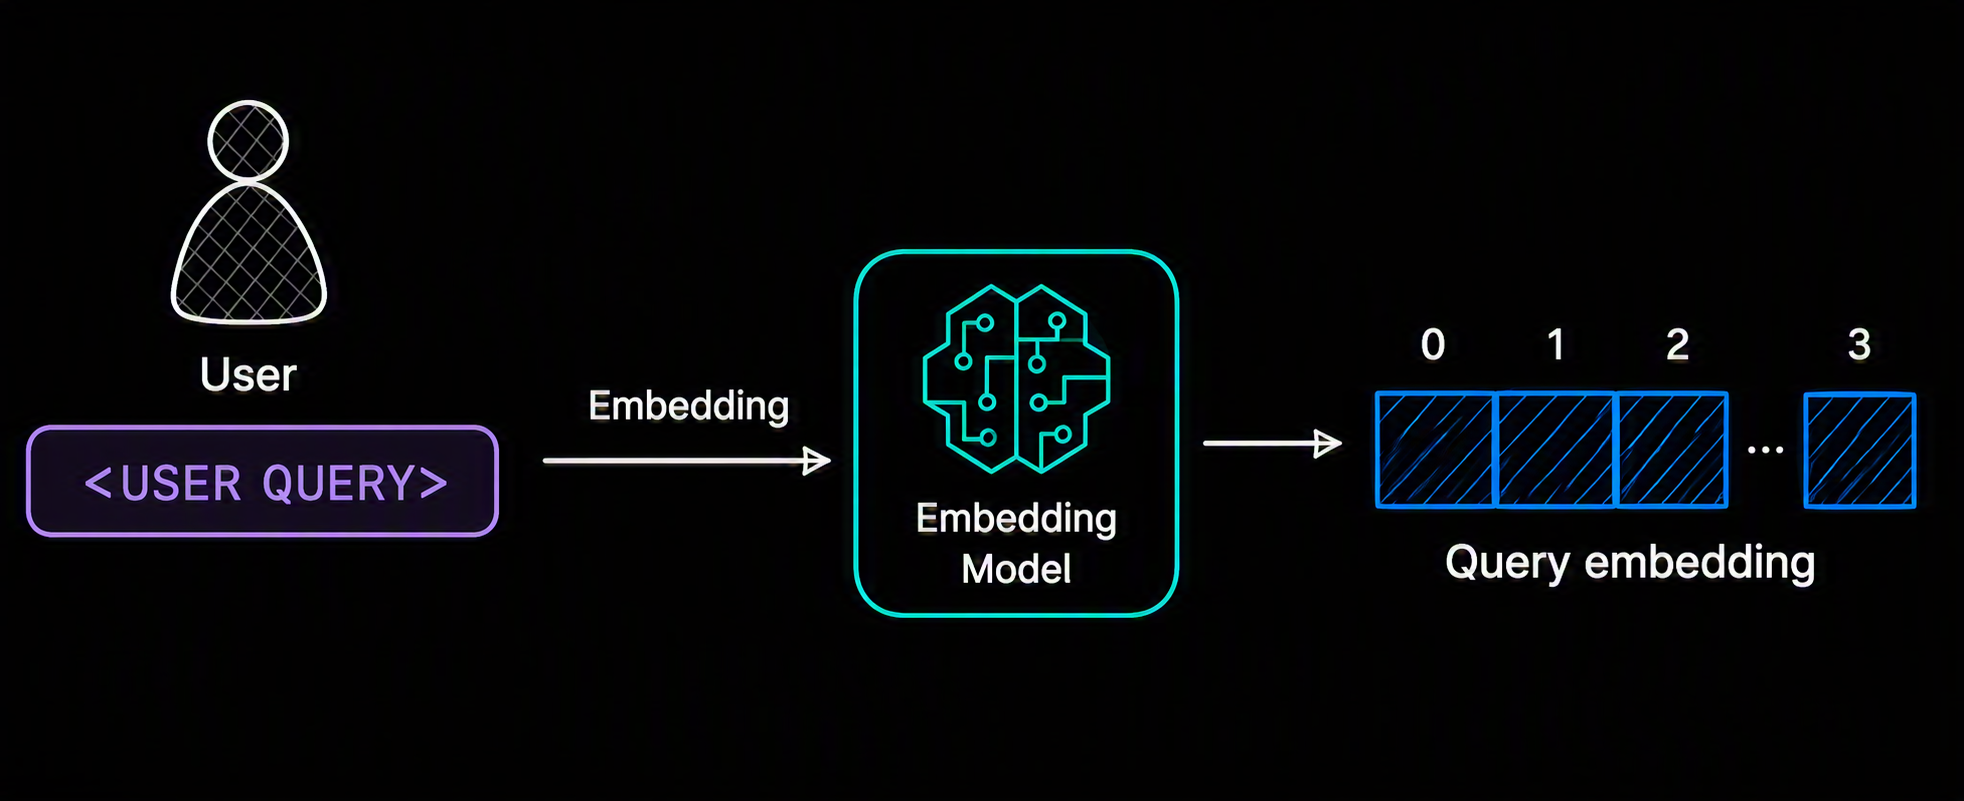

In [18]:
query = "Como devo proceder se eu tiver um item comprado roubado?"

In [19]:
query_embed = embeddings_model.embed_query(query)

In [20]:
query_embed

[0.007676602806895971,
 -0.002539908979088068,
 -0.007780604064464569,
 -0.04058654233813286,
 -0.03026440553367138,
 0.024024322628974915,
 -0.007176096085458994,
 -0.03666049242019653,
 0.0038903020322322845,
 -0.010757643729448318,
 0.007260597310960293,
 -0.015249203890562057,
 0.0102311372756958,
 -0.02117728441953659,
 0.0015892712399363518,
 0.008235610090196133,
 0.017329232767224312,
 0.0026569105684757233,
 0.020280271768569946,
 -0.008807618170976639,
 -0.017849238589406013,
 0.01032863836735487,
 0.0020849029533565044,
 -0.02709236368536949,
 -0.0015348331071436405,
 -0.0076701026409864426,
 0.013832185417413712,
 -0.003360545029863715,
 0.03187642619013786,
 -0.016120215877890587,
 0.020319271832704544,
 -0.00015376768715213984,
 -0.018668249249458313,
 -0.010491140186786652,
 -0.019669262692332268,
 0.01813524216413498,
 0.01933125965297222,
 0.00713059538975358,
 -0.003958553075790405,
 0.016835225746035576,
 0.014287191443145275,
 0.0007767603965476155,
 0.0200202688574

In [21]:
similar_chunks = retriever.invoke(query)
similar_chunks

[Document(id='a6f47713-a933-4be8-9f11-3137ce9c6b55', metadata={'source': '/content/GTB_gold_Nov23.txt'}, page_content='Seguro Garantia Estendida Original .............................................................................. 3 \nCompra Protegida ........................................................................................................ 8 \nProteção de Preço ....................................................................................................... 12 \nPrincipais Termos e Definições (Em Geral) .................................................................... 17 \nComo Dar Entrada em uma ocorrência/sinistro ........................................................... 18 \nMastercard Global Service .......................................................................................... 21 \nDisposições Gerais e Limitação de Responsabilidade .................................................... 23'),
 Document(id='dbba87d3-ee7a-4e4a-8895-884bd47d6d20', 

## Resgatar os documentos similares no Banco

In [22]:
similar_texts = [pedaco.page_content for pedaco in similar_chunks]

similar_texts

['Seguro Garantia Estendida Original .............................................................................. 3 \nCompra Protegida ........................................................................................................ 8 \nProteção de Preço ....................................................................................................... 12 \nPrincipais Termos e Definições (Em Geral) .................................................................... 17 \nComo Dar Entrada em uma ocorrência/sinistro ........................................................... 18 \nMastercard Global Service .......................................................................................... 21 \nDisposições Gerais e Limitação de Responsabilidade .................................................... 23',
 'uma perda ou pedido de serviços forem efetuados, se você intencionalmente ocultar ou fizer \ninterpretação  errônea  de  qualquer  fato  material  ou  circunstância,  ou

In [28]:
sources = list(set([ chunk.metadata['source'] for chunk in similar_chunks ]))
sources

['/content/GTB_gold_Nov23.txt']

In [27]:
from langchain_core.prompts import ChatPromptTemplate

prompt_consulta_seguro = ChatPromptTemplate.from_messages(
    [
        ("system", "Responda usando exclusivamente o conteúdo fornecido. \n\nContexto: \n{contexto}"),
        ("human", "{query}")
    ]
)

## Gerar a Resposta

In [32]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

modelo = ChatOpenAI(
    model="gpt-4.1-nano",
    temperature=0.5,
    api_key=api_key
)

def no_rag(pergunta):
  return modelo.invoke(pergunta)

def rag(pergunta):
  cadeia = prompt_consulta_seguro | modelo | StrOutputParser()
  # retrieve
  trechos = retriever.invoke(query)
  # augment
  contexto = "\n\n".join(um_trecho.page_content for um_trecho in trechos)
  # generate
  return cadeia.invoke({ "query": pergunta, "contexto": contexto})

In [33]:
query

'Como devo proceder se eu tiver um item comprado roubado?'

In [36]:
no_rag(query).content

'Se você comprou um item que foi posteriormente roubado, é importante agir de forma responsável e seguir alguns passos para resolver a situação. Aqui estão as recomendações:\n\n1. **Entre em contato com o vendedor:** Informe imediatamente ao vendedor ou à loja onde adquiriu o item sobre a suspeita ou confirmação de que ele foi roubado. Isso ajuda a evitar que o item continue sendo vendido de forma ilícita e que você possa colaborar com as investigações.\n\n2. **Não tente vender ou usar o item:** Para evitar problemas legais, não utilize, venda ou distribua o item roubado.\n\n3. **Procure as autoridades policiais:** Se você tiver provas de que o item é roubado (por exemplo, nota fiscal, recibo, ou informações do vendedor), registre um boletim de ocorrência na delegacia mais próxima. Isso é importante para regularizar sua situação e evitar implicações legais futuras.\n\n4. **Forneça informações relevantes:** Ao registrar o boletim, forneça o máximo de detalhes possível, como a origem do 

In [35]:
rag(query)

'Para dar entrada em uma ocorrência ou sinistro relacionado a um item comprado roubado, você deve ligar para o número gratuito do Mastercard Global Service™ específico para o seu país, ou ligar a cobrar para os Estados Unidos no número 1-636-722-8881 (Português).'